# INSID3-Instance — iterative foreground-crop re-embedding

**Idea.** DINOv3 resizes *any* input to `image_size x image_size` before patchifying, so the
patch grid (e.g. 64x64) is a **fixed budget**. When instances occupy a small part of the
frame, most patches are spent on background. If we **crop to the foreground and re-embed**,
that budget is handed to the instances: each instance now spans many more patches.

This notebook runs the loop

```
round r:  embed(image_r) -> gate -> foreground_r
          crop image_r to the foreground bbox -> image_{r+1}
```

and asks: **how does the PCA / feature structure change as we zoom in?**

What we expect to see:
1. **Resolution boost** — foreground patch count grows sharply round-to-round.
2. **PCA variance reallocates** — on the full image, PC1 mostly encodes *figure vs ground*;
   after cropping (almost all foreground), the top PCs encode *inter-/intra-instance*
   structure instead. So the explained-variance curve and the PCA-RGB both change character.
3. **Sharper seams** — the feature-boundary cue between touching instances strengthens,
   which is exactly what the individuation stage needs.

> Requires gated DINOv3 weights (`HF_ACCESS_TOKEN`).

## 0 · Setup

In [1]:
import os, sys, json
from pathlib import Path

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
os.chdir(ROOT)

import numpy as np
import torch
import cv2
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.decomposition import PCA

from dotenv import load_dotenv
load_dotenv(ROOT / ".env")
plt.rcParams["figure.dpi"] = 110

def pca_rgb(features, mask=None):
    """3-component PCA of an (Hp,Wp,D) feature grid -> RGB image in [0,1].
    If mask (Hp,Wp bool) is given, PCA is fit on those patches only."""
    Hp, Wp, D = features.shape
    flat = features.reshape(Hp * Wp, D).cpu().numpy()
    fit = flat[mask.reshape(-1)] if mask is not None and mask.any() else flat
    p = PCA(3).fit(fit)
    rgb = p.transform(flat).reshape(Hp, Wp, 3)
    rgb = (rgb - rgb.min()) / (np.ptp(rgb) + 1e-8)
    return rgb, p

def label_cmap(n):
    rng = np.random.default_rng(7)
    colors = rng.random((max(n, 1) + 1, 3)); colors[0] = 0
    return ListedColormap(colors)

def fg_contour(image, foreground_grid):
    """Draw the patch-grid foreground boundary on a copy of image."""
    h, w = image.shape[:2]
    fg = cv2.resize(foreground_grid.astype(np.uint8), (w, h), interpolation=cv2.INTER_NEAREST)
    cnts, _ = cv2.findContours(fg, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    out = image.copy()
    cv2.drawContours(out, cnts, -1, (0, 255, 0), max(1, h // 200))
    return out

## 1 · Load a coral image + one exemplar fragment

20220309T1430_CBASS_US_Thatch_Ofav_32.5_T1_10-13.JPG  4000x3000  |  4 fragments; using 1 as exemplar


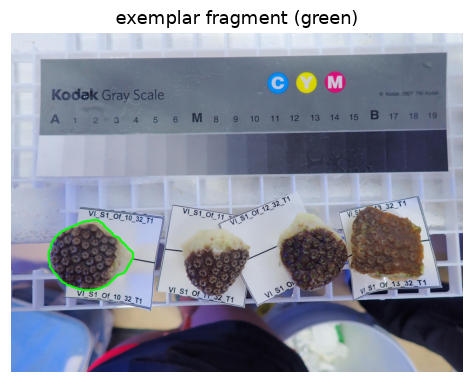

In [2]:
DATA = ROOT.parent / "backend" / "data" / "datasets" / "Global Search Dataset"
coco = json.load(open(DATA / "Global_Search_Dataset_coco.json"))
from collections import Counter
img_id = Counter(a["image_id"] for a in coco["annotations"]).most_common(1)[0][0]
img_meta = next(im for im in coco["images"] if im["id"] == img_id)
image = cv2.cvtColor(cv2.imread(str(DATA / "images" / img_meta["file_name"])), cv2.COLOR_BGR2RGB)
H, W = image.shape[:2]
sx, sy = W / img_meta["width"], H / img_meta["height"]
CORAL = next(c["id"] for c in coco["categories"] if c["name"] == "Coral Fragment")
anns = [a for a in coco["annotations"] if a["image_id"] == img_id and a["category_id"] == CORAL]

def poly_to_mask(ann):
    m = np.zeros((H, W), np.uint8)
    for poly in ann["segmentation"]:
        pts = np.array(poly, float).reshape(-1, 2); pts[:, 0] *= sx; pts[:, 1] *= sy
        cv2.fillPoly(m, [pts.astype(np.int32)], 1)
    return m

gt = [m for m in (poly_to_mask(a) for a in anns) if m.sum() > 0]
areas = [m.sum() for m in gt]
positive_masks = [gt[int(np.argsort(areas)[len(areas) // 2])]]
print(f"{img_meta['file_name']}  {W}x{H}  |  {len(gt)} fragments; using 1 as exemplar")
plt.figure(figsize=(6, 4)); plt.imshow(fg_contour(image, cv2.resize(positive_masks[0], (W, H)) > 0))
plt.axis("off"); plt.title("exemplar fragment (green)"); plt.show()

## 2 · Run the refinement loop

`iterative_refine` embeds, gates, crops to the foreground, and repeats, returning one `RefineRound` per iteration with all intermediates.

In [3]:
from iquana_toolbox.ai.backbones.dinov3 import DINOv3Backbone, DEFAULT_DINOV3_MODEL
from models.insid3 import refine
from models.insid3.pipeline import InSID3Params

backbone = DINOv3Backbone(model_id=DEFAULT_DINOV3_MODEL, image_size=1024, token=os.getenv("HF_ACCESS_TOKEN"))
params = InSID3Params(gate_threshold=0.55)

history = refine.iterative_refine(backbone, image, positive_masks, params, rounds=4, pad_frac=0.06)
for h in history:
    Hp, Wp = h.grid_hw
    fg = int(h.gate.foreground.sum())
    print(f"round {h.index}: image {h.image.shape[1]}x{h.image.shape[0]}  "
          f"grid {Hp}x{Wp}  foreground {fg}/{Hp*Wp} patches ({100*fg/(Hp*Wp):.1f}%)  "
          f"next_crop={h.crop_box}")

C:\Users\role01-admin\PycharmProjects\iquana\instance-discovery-service\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 211/211 [00:00<00:00, 7527.35it/s]


round 0: image 4000x3000  grid 64x64  foreground 691/4096 patches (16.9%)  next_crop=(1494, 2491, 103, 4000)
round 1: image 3897x997  grid 64x64  foreground 1646/4096 patches (40.2%)  next_crop=(0, 923, 43, 3794)
round 2: image 3751x923  grid 64x64  foreground 1702/4096 patches (41.6%)  next_crop=None


## 3 · How the PCA changes, round by round

Top row: the (cropped) image with the gated foreground outlined. Bottom row: PCA-RGB of the DINOv3 features (PCA fit on **all** patches of that round). Watch the foreground fill the frame and the PCA-RGB shift from *figure-vs-ground* coloring toward *per-instance* coloring.

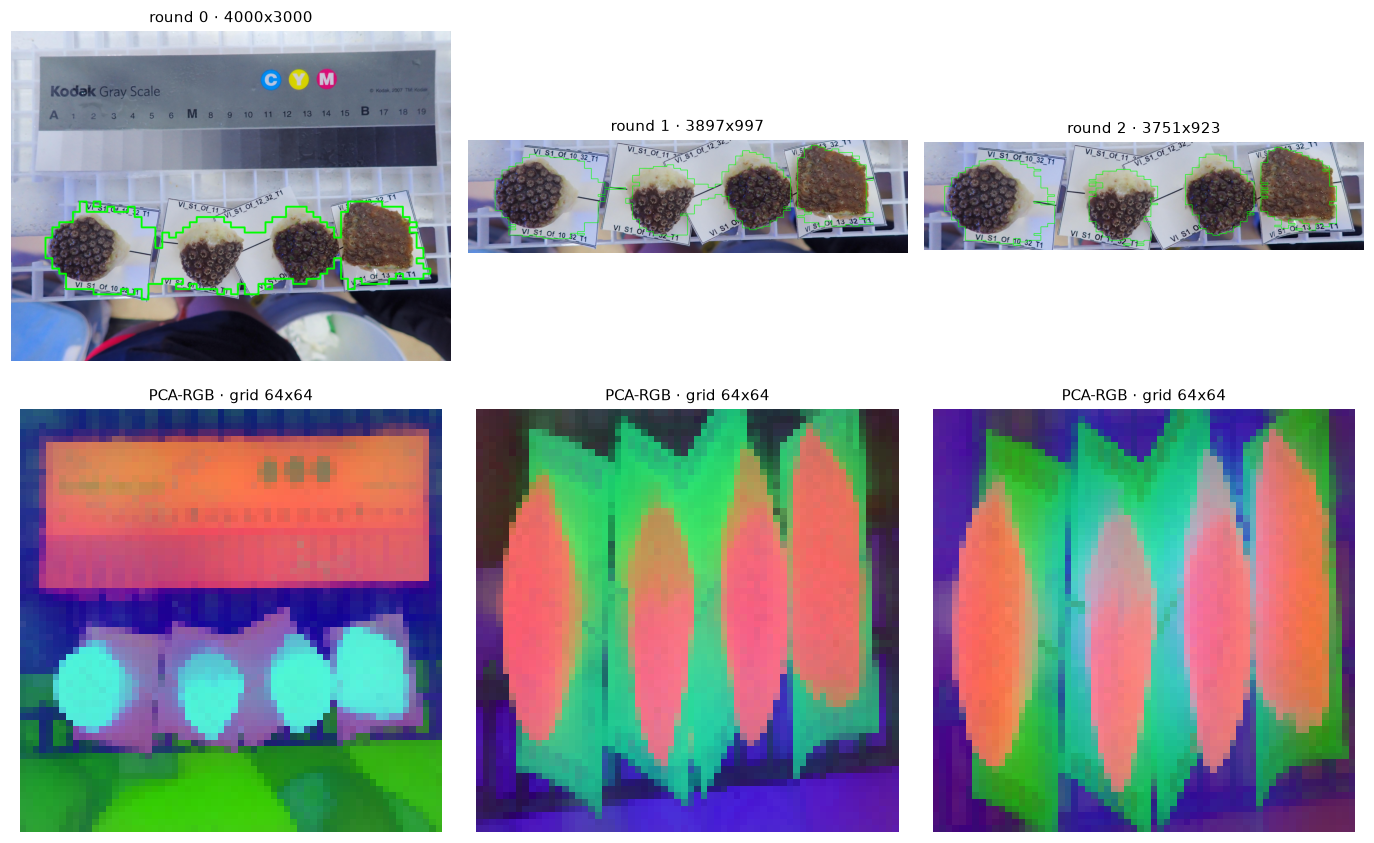

In [4]:
n = len(history)
fig, axes = plt.subplots(2, n, figsize=(4.2 * n, 8))
axes = np.atleast_2d(axes)
for j, h in enumerate(history):
    rgb, _ = pca_rgb(h.features)
    axes[0, j].imshow(fg_contour(h.image, h.gate.foreground)); axes[0, j].axis("off")
    axes[0, j].set_title(f"round {h.index} · {h.image.shape[1]}x{h.image.shape[0]}", fontsize=10)
    axes[1, j].imshow(rgb); axes[1, j].axis("off")
    axes[1, j].set_title(f"PCA-RGB · grid {h.grid_hw[0]}x{h.grid_hw[1]}", fontsize=10)
plt.tight_layout(); plt.show()

## 4 · PCA variance: figure-ground → instance structure

For each round we fit PCA on **all** patches and on **foreground-only** patches. Two signals:

* **Full-image top-PC variance** drops as we zoom in — round 0 is dominated by the huge background/foreground contrast (a few PCs explain most variance); later rounds are almost all foreground, so variance spreads across more components (finer structure).
* **Foreground-only** PCA isolates the class structure regardless of crop, giving a fair view of how much intra-class detail is resolved.

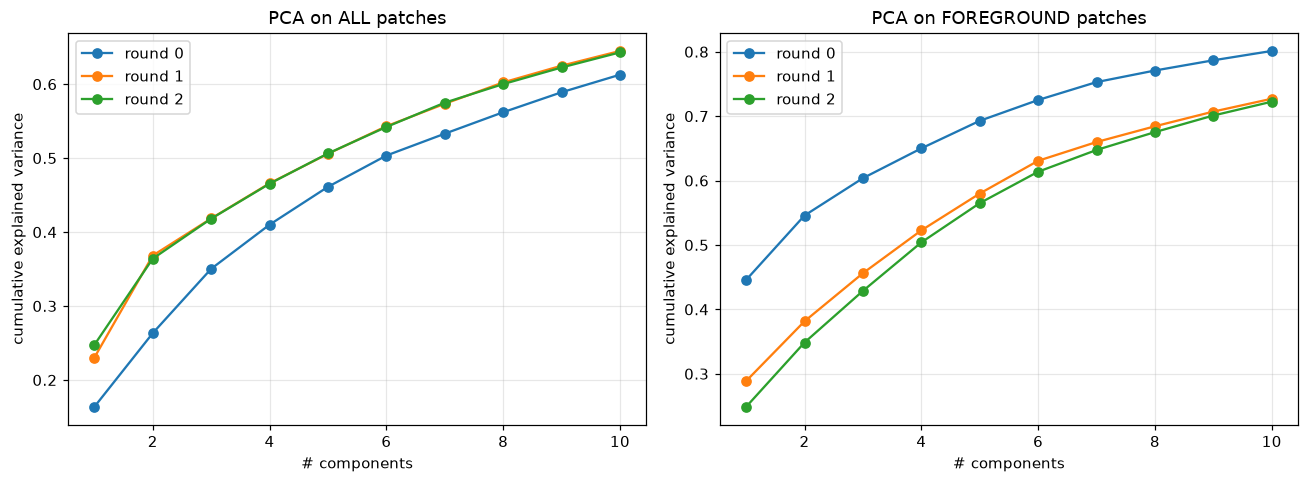

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
K = 10
for h in history:
    Hp, Wp, D = h.features.shape
    flat = h.features.reshape(Hp * Wp, D).cpu().numpy()
    fgm = h.gate.foreground.reshape(-1)
    ev_all = PCA(K).fit(flat).explained_variance_ratio_
    ax[0].plot(np.arange(1, K + 1), np.cumsum(ev_all), marker="o", label=f"round {h.index}")
    if fgm.sum() > K:
        ev_fg = PCA(K).fit(flat[fgm]).explained_variance_ratio_
        ax[1].plot(np.arange(1, K + 1), np.cumsum(ev_fg), marker="o", label=f"round {h.index}")
for a, t in zip(ax, ["PCA on ALL patches", "PCA on FOREGROUND patches"]):
    a.set_xlabel("# components"); a.set_ylabel("cumulative explained variance")
    a.set_title(t); a.grid(alpha=0.3); a.legend()
plt.tight_layout(); plt.show()

## 5 · Resolution and seam sharpness vs round

Quantifying the two effects that matter for individuation: foreground patch count (effective resolution) and the mean feature-boundary strength inside the foreground (seam sharpness).

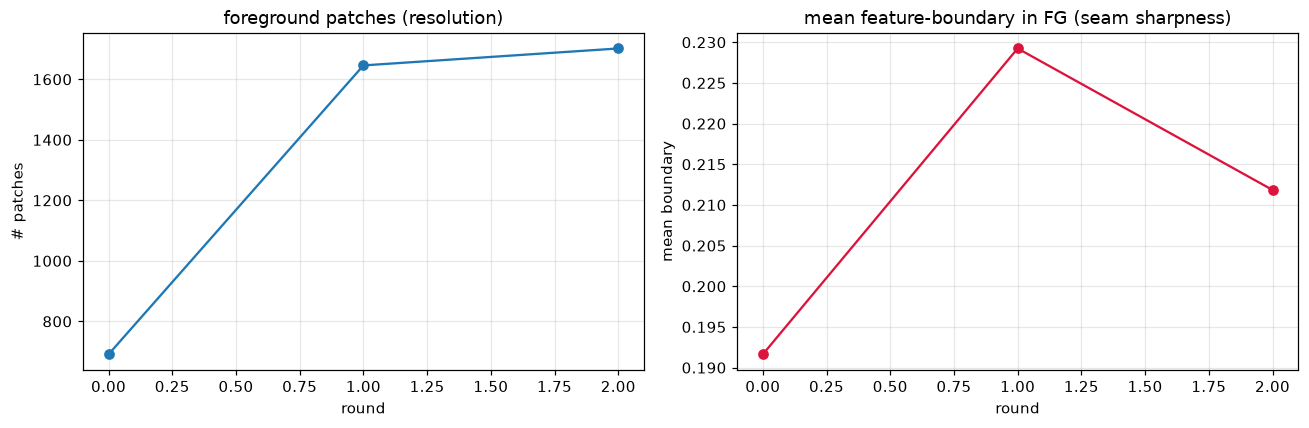

foreground patches per round: [691, 1646, 1702]
seam sharpness per round:     [0.192, 0.229, 0.212]


In [6]:
from models.insid3.individuation import feature_boundary_map

rounds = [h.index for h in history]
fg_patches = [int(h.gate.foreground.sum()) for h in history]
seam = []
for h in history:
    fb = feature_boundary_map(h.features, h.gate.foreground)
    fgm = h.gate.foreground
    seam.append(float(fb[fgm].mean()) if fgm.any() else 0.0)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(rounds, fg_patches, marker="o"); ax[0].set_title("foreground patches (resolution)")
ax[0].set_xlabel("round"); ax[0].set_ylabel("# patches"); ax[0].grid(alpha=0.3)
ax[1].plot(rounds, seam, marker="o", color="crimson"); ax[1].set_title("mean feature-boundary in FG (seam sharpness)")
ax[1].set_xlabel("round"); ax[1].set_ylabel("mean boundary"); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()
print("foreground patches per round:", fg_patches)
print("seam sharpness per round:    ", [round(s, 3) for s in seam])

## 6 · Does zooming in help individuation?

Run the full pipeline on the round-0 (full image) features vs the final cropped round, and compare how many instances are recovered. The crop should separate fragments that were merged at coarse resolution.

C:\Users\role01-admin\PycharmProjects\iquana\instance-discovery-service\.venv\Lib\site-packages\sklearn\cluster\_agglomerative.py:595: UserWarning: the number of connected components of the connectivity matrix is 3 > 1. Completing it to avoid stopping the tree early.
  connectivity, n_connected_components = _fix_connectivity(
C:\Users\role01-admin\PycharmProjects\iquana\instance-discovery-service\.venv\Lib\site-packages\sklearn\cluster\_agglomerative.py:595: UserWarning: the number of connected components of the connectivity matrix is 11 > 1. Completing it to avoid stopping the tree early.
  connectivity, n_connected_components = _fix_connectivity(


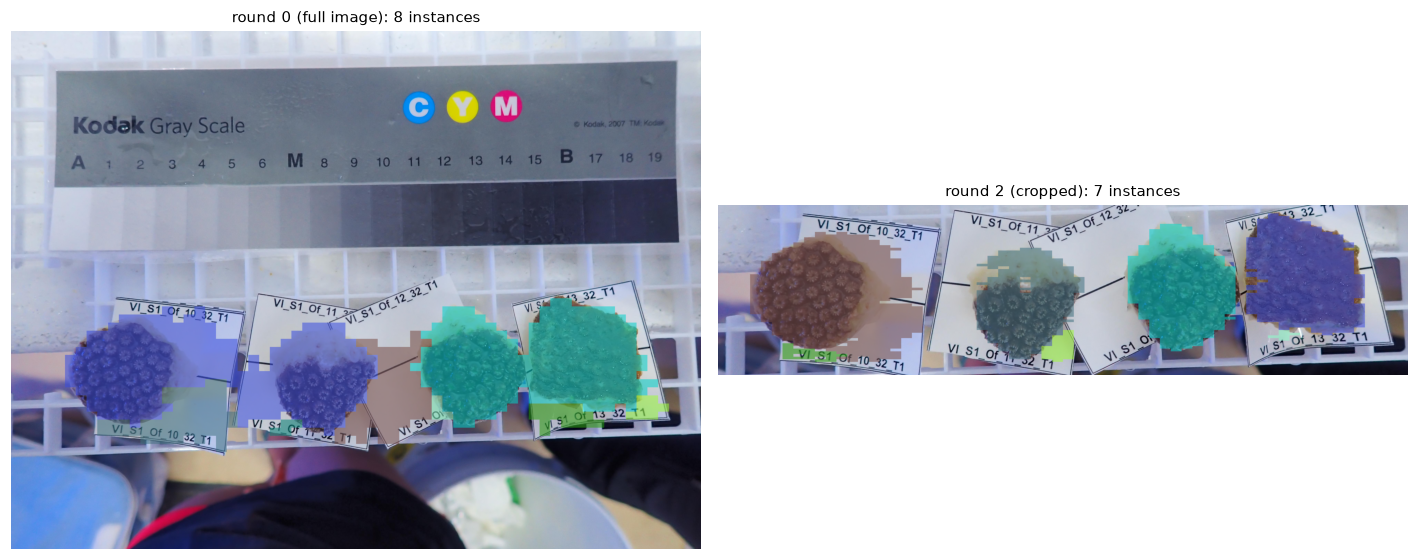

instances  full: 8  cropped: 7


In [7]:
from models.insid3 import pipeline

def overlay(image, labels, alpha=0.55):
    cmap = label_cmap(int(labels.max()))
    colored = cmap(labels / max(labels.max(), 1))[..., :3]
    out = image.astype(float) / 255.0; m = labels > 0
    out[m] = (1 - alpha) * out[m] + alpha * colored[m]; return out

first, last = history[0], history[-1]
res_first = pipeline.run(backbone, first.image, first.exemplar_masks, None, params)
res_last  = pipeline.run(backbone, last.image,  last.exemplar_masks,  None, params)

def to_label(res, shape):
    lab = np.zeros(shape[:2], np.int32)
    for i, m in enumerate(res.instance_masks, 1):
        lab[m > 0] = i
    return lab

fig, ax = plt.subplots(1, 2, figsize=(13, 5.5))
ax[0].imshow(overlay(first.image, to_label(res_first, first.image.shape)))
ax[0].set_title(f"round 0 (full image): {res_first.instance_masks.shape[0]} instances", fontsize=10); ax[0].axis("off")
ax[1].imshow(overlay(last.image, to_label(res_last, last.image.shape)))
ax[1].set_title(f"round {last.index} (cropped): {res_last.instance_masks.shape[0]} instances", fontsize=10); ax[1].axis("off")
plt.tight_layout(); plt.show()
print("instances  full:", res_first.instance_masks.shape[0], " cropped:", res_last.instance_masks.shape[0])

## 7 · Reading the results & caveats

**What the refinement buys you**
- A large jump in foreground patches between round 0 and round 1 = the resolution you were
  missing. This is the cheapest fix for the *patch-limited separation* ceiling — no SAM, no
  training, just spend the patch budget on the instances.
- If the foreground-only PCA curve gets *flatter* (variance spreads across more components)
  while the all-patch curve stays steep early, that confirms new intra-class structure is
  being resolved rather than just figure-ground.

**Caveats**
- **Convergence.** Once the foreground fills the frame, cropping stops changing anything — the
  loop returns early. More rounds ≠ more detail past that point.
- **Coordinates.** Each round lives in its own crop coordinates. To place final masks back on
  the original image, compose the crop boxes (`crop_box` per round) — add an un-crop step if
  you need original-resolution output.
- **A crop that drops instances.** The bbox is taken from the gated foreground; if the gate
  misses a faint instance in round 0, cropping can exclude it permanently. Keep `pad_frac`
  generous, or union the foreground with a dilation before cropping.
- **Single global crop vs per-instance crops.** This notebook crops to the *union* foreground.
  For very different instance scales, a stronger variant is to crop **per detected instance**
  and re-embed each — turning refinement into a coarse-to-fine cascade. That's the natural
  next experiment.